# AF 7: Redes Neuronales Artificiales

---
Hora: N5  Grupo: 007  Salon: 12106

José Juan Tamez Robledo             2001926

Ana Patricia Aguirre Leyzaola       2178178

Jorge Angel de Alejandro Martinez   2066801

Kevin Alejandro Sifuentes Martinez  2067313

Ricardo Alfredo Zumaya Osorio       2178139


---



1. Cargar librerías

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

2. Cargar datos

In [5]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

print("Datos de entrenamiento:", train_data.shape)
print("Etiquetas de entrenamiento:", train_labels.shape)

print("Datos de prueba:", test_data.shape)
print("Etiquetas de prueba:", test_labels.shape)

Datos de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Datos de prueba: (10000, 28, 28)
Etiquetas de prueba: (10000,)


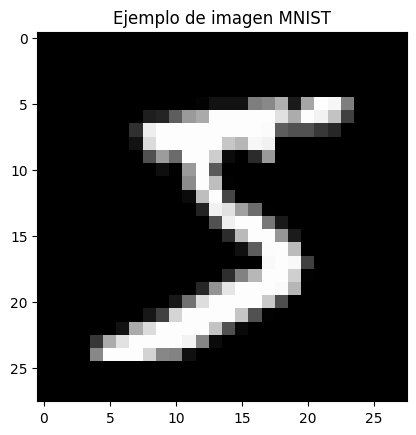

Etiqueta: 5


In [7]:
plt.imshow(train_data[0], cmap="gray")
plt.title("Ejemplo de imagen MNIST")
plt.show()

print("Etiqueta:", train_labels[0])

3. Preprocesamiento

In [10]:
train_data = train_data / 255.0
test_data = test_data / 255.0

In [11]:
train_labels_categorical = to_categorical(train_labels, 10)
test_labels_categorical = to_categorical(test_labels, 10)

print(train_labels[0])
print(train_labels_categorical[0])

5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


4. Selección y entrenamiento del modelo

In [12]:
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_data,
    train_labels_categorical,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7306 - loss: 0.8957 - val_accuracy: 0.8733 - val_loss: 0.4612
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8781 - loss: 0.4268 - val_accuracy: 0.8947 - val_loss: 0.3635
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8967 - loss: 0.3561 - val_accuracy: 0.9097 - val_loss: 0.3119
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9100 - loss: 0.3109 - val_accuracy: 0.9207 - val_loss: 0.2768
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9198 - loss: 0.2759 - val_accuracy: 0.9281 - val_loss: 0.2452
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9274 - loss: 0.2467 - val_accuracy: 0.9344 - val_loss: 0.2209
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9342 - loss: 0.2236 - val_accuracy: 0.9414 - val_loss: 0.2018
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9405 - loss: 0.2028 

5. Prueba del modelo

In [17]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels_categorical)

print("Pérdida en prueba:", test_loss)
print("Exactitud en prueba:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9505 - loss: 0.1662
Pérdida en prueba: 0.16622111201286316
Exactitud en prueba: 0.9505000114440918


Predicciones

In [19]:
predictions = model.predict(test_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Predicción: 7
Valor real: 7


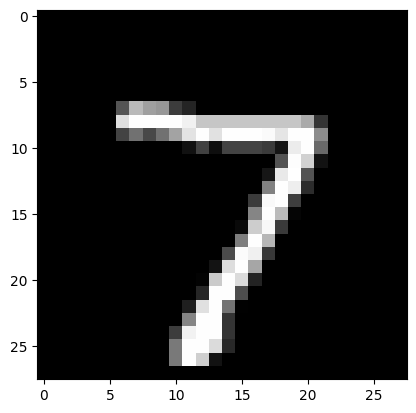

In [20]:
# Predicción 1
indice = 0
print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice], cmap="gray")
plt.show()

Predicción: 0
Valor real: 0


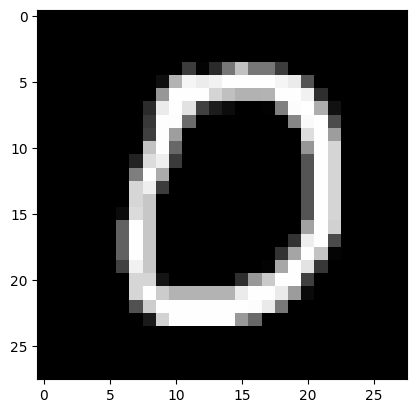

In [21]:
# Predicción 2
indice = 10
print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice], cmap="gray")
plt.show()

Predicción: 0
Valor real: 0


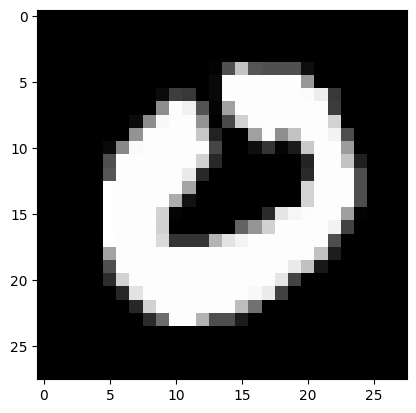

In [22]:
# Predicción 3
indice = 25
print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice], cmap="gray")
plt.show()

Predicción: 6
Valor real: 6


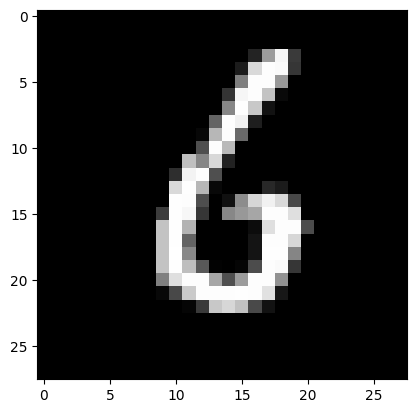

In [23]:
# Predicción 4
indice = 50
print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice], cmap="gray")
plt.show()

Predicción: 6
Valor real: 6


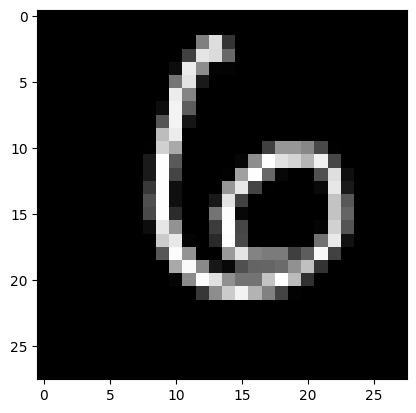

In [24]:
# Predicción 5
indice = 100
print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice], cmap="gray")
plt.show()

Gráfica de entrenamiento

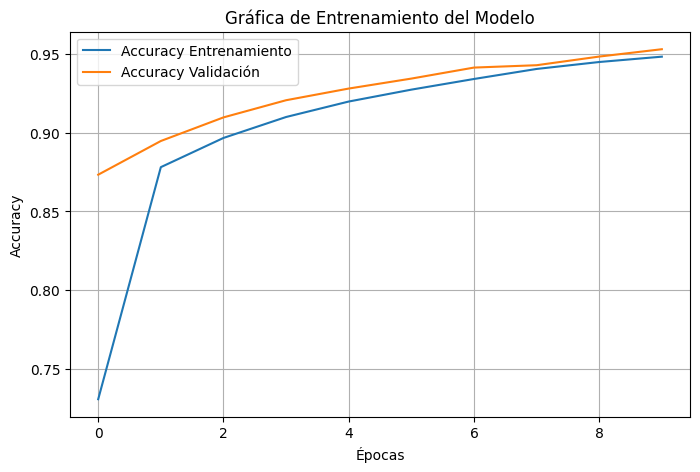

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Accuracy Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Accuracy Validación")

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Gráfica de Entrenamiento del Modelo")

plt.legend()
plt.grid()

plt.show()